In [1]:
import math as m
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
def function(num):
    x = np.linspace(-1.5, 1.5, num)
    f = np.tan(x)
    return f, x

In [3]:
# функция принимает на вход значения функции; значения аргумента; аргумент, где нужно найти значение функции по этим точкам
def Lag(f, x_list, x_value):
    n = len(f)
    if n > 1:
        newf = 0
        for i in range(n):
            product = 1
            for l in range(n):
                if l != i:
                 product *= ((x_value - x_list[l])/(x_list[i] - x_list[l]))
            newf += f[i]*product
    else:
        newf = f[0]
    return newf

In [4]:
def div_dif(f, x):  # разделённая разность
    dsum = 0
    for j in range(len(f)):
        denominator = 1
        for i in range(len(f)):
            if j != i:
                denominator *= x[j] - x[i]
        dsum += f[j]/denominator
    return dsum

In [5]:
def DL(f, x, x_value):  # Ln-Ln-1
    n = len(f)
    product = div_dif(f, x)
    for l in range(n-1):
        product *= (x_value - x[l]) 
    return product

In [6]:
def Newton(f, x, x_value, n):
    newt = Lag(f[:1], x[:1], x_value)
    for i in range(1, n):
        newt += DL(f[:i+1], x[:i+1], x_value)
    return newt

In [7]:
# ячейка для проверки разделенной разности
f0 = np.array([1, 3, 2, 5])
x0 = np.array([0, 2, 3, 5])
summ = div_dif(f0[:4], x0[:4])
summ

0.30000000000000004

In [8]:
# ячейка для проверки разницы полиномов
L10 = DL(f0[:2], x0[:2], 4)
L21 = DL(f0[:3], x0[:3], 4)
L32 = DL(f0[:4], x0[:4], 4)
print(L10)
print(L21)
print(L32)

4.0
-5.333333333333333
2.4000000000000004


In [9]:
# ячейка для проверки
x = [0, 2, 3, 5]
y = [1, 3, 2, 5]

newx = 4
newf2 = -(2/3)*newx**2 + (7/3)*newx + 1
newf3 = (3/10)*newx**3 - (13/6)*newx**2 + (62/15)*newx + 1

newfL = Lag(y, x, newx)
newfN = Newton(y, x, newx, len(y))
print(newf3, newfL, newfN)

2.06666666666667 2.0666666666666664 2.0666666666666673


In [10]:
f = function(7)[0]   # исходные значения, по которым будет строиться функция
x = function(7)[1]

f_real, x2 = function(50) # истинные значения функции, значения аргумента
f2 = []  # список со значениями, которые будут вычисляться, Лагранж
f3 = []

for c in x2:
    f2.append(Lag(f, x, c))
    f3.append(Newton(f, x, c, len(f)))

DLag = f_real - np.array(f2)
DNew = f_real - np.array(f3)

big_function_for_graph, big_x_for_graph = function(1000) 


In [11]:
x

array([-1.5, -1. , -0.5,  0. ,  0.5,  1. ,  1.5])

<function matplotlib.pyplot.show(close=None, block=None)>

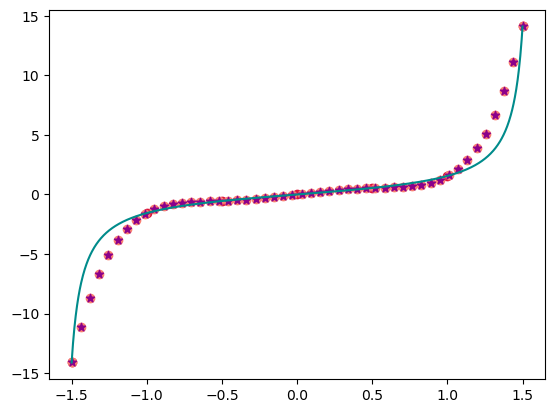

In [12]:
fig1 = plt.figure()
ax1 = fig1.add_subplot(111)
#ax1.set_title(' ')
#ax1.set_xlabel('V')
#ax1.set_ylabel('$p_i$')
plt.scatter(x, f, color='crimson')
plt.scatter(x2, f2, color='salmon')
plt.scatter(x2, f3, color='darkmagenta', marker='*')
plt.plot(big_x_for_graph, big_function_for_graph, color='darkcyan')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

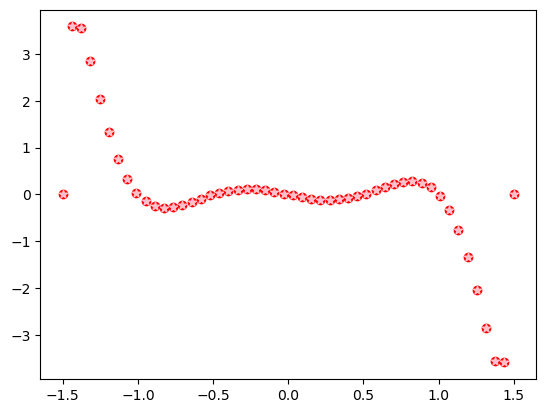

In [13]:
fig1 = plt.figure()
ax1 = fig1.add_subplot(111)
#ax1.set_title(' ')
#ax1.set_xlabel('V')
#ax1.set_ylabel('$p_i$')
plt.scatter(x2, DLag, color='red')
plt.scatter(x2, DNew, color='pink', marker='*')
plt.show